In [1]:
import polars as pl
import matplotlib.pyplot as plt

# Build one lazy scan over all parquet files
lf = pl.scan_parquet("Faradayv5/*.parquet")

# Get shape (rows, columns) without loading full data into memory
row_count = lf.select(pl.len().alias("row_count")).collect(engine='streaming').item()
column_names = lf.collect_schema().names()
column_types = lf.collect_schema().dtypes()

print("Dataset format: parquet")
print(f"Dataset shape: ({row_count}, {len(column_names)})")

# Show column names + data types
schema_table = pl.DataFrame(
    {
        "name": column_names,
        "dtype": [str(dt) for dt in column_types],
    }
).sort("name")

schema_table


Dataset format: parquet
Dataset shape: (10000000, 13)


name,dtype
str,str
"""cluster_label""","""Int64"""
"""day_of_week""","""String"""
"""energy_rating""","""String"""
"""has_electric_hot_water""","""Boolean"""
"""has_electric_radiator""","""Boolean"""
…,…
"""has_solar_pv""","""Boolean"""
"""kwh""","""Binary"""
"""month_of_year""","""String"""


In [2]:
lf = pl.scan_parquet("Faradayv5/*.parquet")

property_types = (
    lf.select(pl.col("property_type_2"))
    .drop_nulls()
    .unique()
    .sort("property_type_2")
    .collect(engine='streaming')["property_type_2"]
    .to_list()
)

energy_ratings = (
    lf.select(pl.col("energy_rating"))
    .drop_nulls()
    .unique()
    .sort("energy_rating")
    .collect(engine='streaming')["energy_rating"]
    .to_list()
)

tariff_types = (
    lf.select(pl.col("tariff_type"))
    .drop_nulls()
    .unique()
    .sort("tariff_type")
    .collect(engine='streaming')["tariff_type"]
    .to_list()
)

print("Unique property_type_2:", property_types)
print("Unique energy_rating:", energy_ratings)
print("Unique tariff_type:", tariff_types)


Unique property_type_2: ['Bungalow', 'Detached', 'Flat', 'Semi_Detached', 'Terraced']
Unique energy_rating: ['A_B_C', 'D_E', 'F_G']
Unique tariff_type: ['automated', 'eco', 'smart', 'standard']


In [3]:
asset_counts = (
    pl.scan_parquet('Faradayv5/*.parquet')
    .group_by('tariff_type')
    .agg(
        pl.col('has_heat_pump').sum().alias('heat_pump_count'),
        pl.col('has_solar_pv').sum().alias('solar_pv_count'),
        pl.col('has_electric_vehicle').sum().alias('ev_count'),
        pl.col('has_electric_hot_water').sum().alias('electric_hw')
    )
    .collect()
)

print(asset_counts)

shape: (4, 5)
┌─────────────┬─────────────────┬────────────────┬──────────┬─────────────┐
│ tariff_type ┆ heat_pump_count ┆ solar_pv_count ┆ ev_count ┆ electric_hw │
│ ---         ┆ ---             ┆ ---            ┆ ---      ┆ ---         │
│ str         ┆ u32             ┆ u32            ┆ u32      ┆ u32         │
╞═════════════╪═════════════════╪════════════════╪══════════╪═════════════╡
│ smart       ┆ 189106          ┆ 1345669        ┆ 785306   ┆ 79126       │
│ standard    ┆ 35201           ┆ 109188         ┆ 175389   ┆ 37283       │
│ automated   ┆ 75580           ┆ 412076         ┆ 1110723  ┆ 79688       │
│ eco         ┆ 52790           ┆ 97996          ┆ 151554   ┆ 18994       │
└─────────────┴─────────────────┴────────────────┴──────────┴─────────────┘


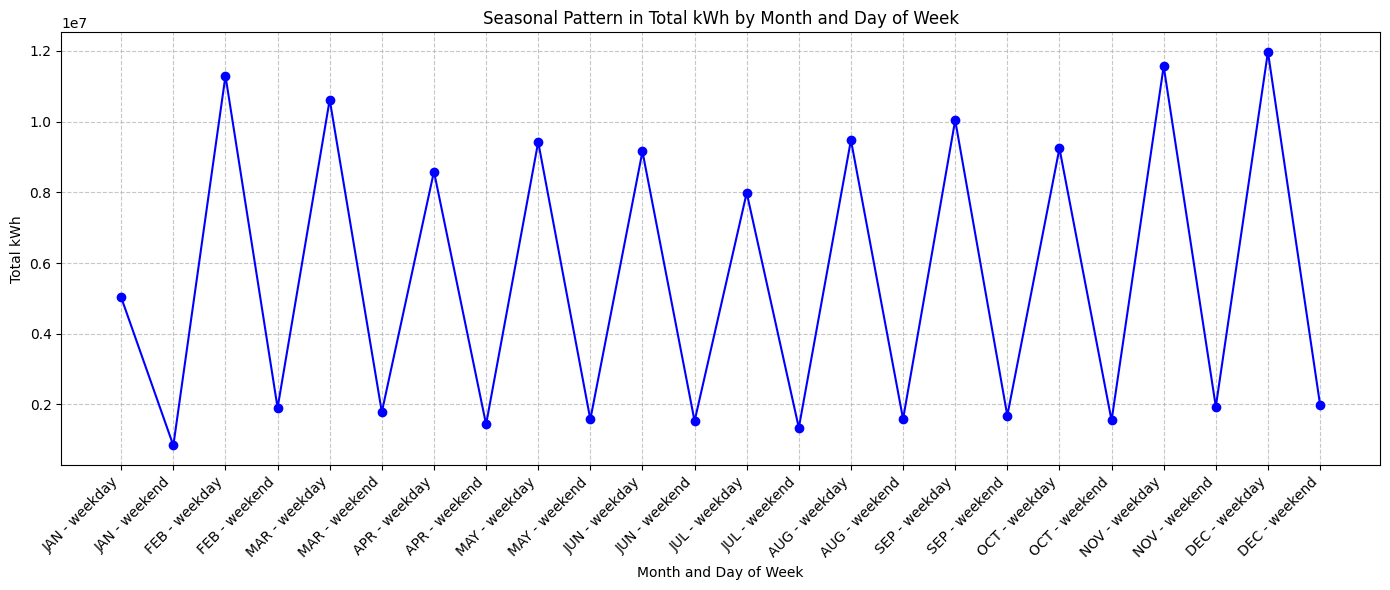

In [4]:
# Summing the 48 half-hour values for each row, then grouping by month and day_of_week.
seasonal_data = (
    pl.scan_parquet('Faradayv5/*.parquet')
    .with_columns(pl.col('kwh').cast(pl.String).str.json_decode(pl.List(pl.Float64)))
    .with_columns(pl.col('kwh').list.sum().alias('daily_kwh'))
    .group_by('month_of_year', 'day_of_week')
    .agg(pl.col('daily_kwh').sum().alias('total_kwh'))
    .collect(engine='streaming')
)

# Sort chronologically using a numeric month index.
month_order = ['JAN', 'FEB', 'MAR', 'APR', 'MAY', 'JUN', 'JUL', 'AUG', 'SEP', 'OCT', 'NOV', 'DEC']
month_index = {m: i for i, m in enumerate(month_order)}

plot_df = (
    seasonal_data
    .with_columns(pl.col('month_of_year').replace_strict(month_index).alias('month_idx'))
    .sort(['month_idx', 'day_of_week'])
    .with_columns((pl.col('month_of_year') + pl.lit(' - ') + pl.col('day_of_week')).alias('x_label'))
)

# Plot seasonal pattern.
plt.figure(figsize=(14, 6))
plt.plot(plot_df['x_label'].to_list(), plot_df['total_kwh'].to_list(), marker='o', linestyle='-', color='b')
plt.xticks(rotation=45, ha='right')
plt.xlabel('Month and Day of Week')
plt.ylabel('Total kWh')
plt.title('Seasonal Pattern in Total kWh by Month and Day of Week')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt


def _as_list(value):
    if value is None:
        return None
    if isinstance(value, str):
        return [value]
    return list(value)


def _to_wide(scan, kwh_col='kwh', prefix='hh_'):
    schema = scan.collect_schema().names()
    if kwh_col not in schema:
        return scan
    wide_exprs = [pl.col(kwh_col).list.get(i).alias(f'{prefix}{i:02d}') for i in range(48)]
    return scan.with_columns(wide_exprs).drop(kwh_col)


def extract_by_property_type(property_types, parquet_path='Faradayv5/*.parquet', columns=None, wide=True, streaming=True):
    property_types = _as_list(property_types)
    scan = pl.scan_parquet(parquet_path).filter(pl.col('property_type_2').is_in(property_types))
    scan = scan.with_columns(pl.col('kwh').cast(pl.String).str.json_decode(pl.List(pl.Float64)))
    if columns:
        base_cols = ['property_type_2', 'energy_rating', 'tariff_type', 'kwh']
        selected = list(dict.fromkeys(base_cols + columns))
        scan = scan.select([c for c in selected if c in scan.collect_schema().names()])
    if wide:
        scan = _to_wide(scan)
    return scan.collect(engine='streaming' if streaming else 'auto')


def extract_by_energy_rating(energy_ratings, parquet_path='Faradayv5/*.parquet', columns=None, wide=True, streaming=True):
    energy_ratings = _as_list(energy_ratings)
    scan = pl.scan_parquet(parquet_path).filter(pl.col('energy_rating').is_in(energy_ratings))
    scan = scan.with_columns(pl.col('kwh').cast(pl.String).str.json_decode(pl.List(pl.Float64)))
    if columns:
        base_cols = ['property_type_2', 'energy_rating', 'tariff_type', 'kwh']
        selected = list(dict.fromkeys(base_cols + columns))
        scan = scan.select([c for c in selected if c in scan.collect_schema().names()])
    if wide:
        scan = _to_wide(scan)
    return scan.collect(engine='streaming' if streaming else 'auto')


def extract_filtered(property_types=None, energy_ratings=None, tariff_types=None, parquet_path='Faradayv5/*.parquet', columns=None, wide=True, streaming=True):
    scan = pl.scan_parquet(parquet_path)
    property_types = _as_list(property_types)
    energy_ratings = _as_list(energy_ratings)
    tariff_types = _as_list(tariff_types)
    if property_types is not None:
        scan = scan.filter(pl.col('property_type_2').is_in(property_types))
    if energy_ratings is not None:
        scan = scan.filter(pl.col('energy_rating').is_in(energy_ratings))
    if tariff_types is not None:
        scan = scan.filter(pl.col('tariff_type').is_in(tariff_types))
    scan = scan.with_columns(pl.col('kwh').cast(pl.String).str.json_decode(pl.List(pl.Float64)))
    if columns:
        base_cols = ['property_type_2', 'energy_rating', 'tariff_type', 'kwh']
        selected = list(dict.fromkeys(base_cols + columns))
        scan = scan.select([c for c in selected if c in scan.collect_schema().names()])
    if wide:
        scan = _to_wide(scan)
    return scan.collect(engine='streaming' if streaming else 'auto')


def aggregate_wide_by_tariff(df, tariff_col='tariff_type', hh_prefix='hh_'):
    hh_cols = [f'{hh_prefix}{i:02d}' for i in range(48) if f'{hh_prefix}{i:02d}' in df.columns]
    if not hh_cols:
        raise ValueError('No wide half-hour columns found')
    return df.group_by(tariff_col).agg([pl.col(c).mean().alias(c) for c in hh_cols])


def visualize_by_tariff_type(df, tariff_col='tariff_type', hh_prefix='hh_', title='Average kWh by Tariff Type over 48 Half-Hours'):
    aggregated = aggregate_wide_by_tariff(df, tariff_col=tariff_col, hh_prefix=hh_prefix)
    hh_cols = [f'{hh_prefix}{i:02d}' for i in range(48) if f'{hh_prefix}{i:02d}' in aggregated.columns]
    plt.figure(figsize=(12, 6))
    for row in aggregated.iter_rows(named=True):
        plt.plot(list(range(len(hh_cols))), [row[c] for c in hh_cols], label=row[tariff_col])
    plt.xlabel('Half-Hour Index (hh_index)')
    plt.ylabel('Average Energy Consumption (avg_kwh)')
    plt.title(title)
    plt.legend(title='Tariff Type')
    plt.grid(True)
    plt.tight_layout()
    plt.show()




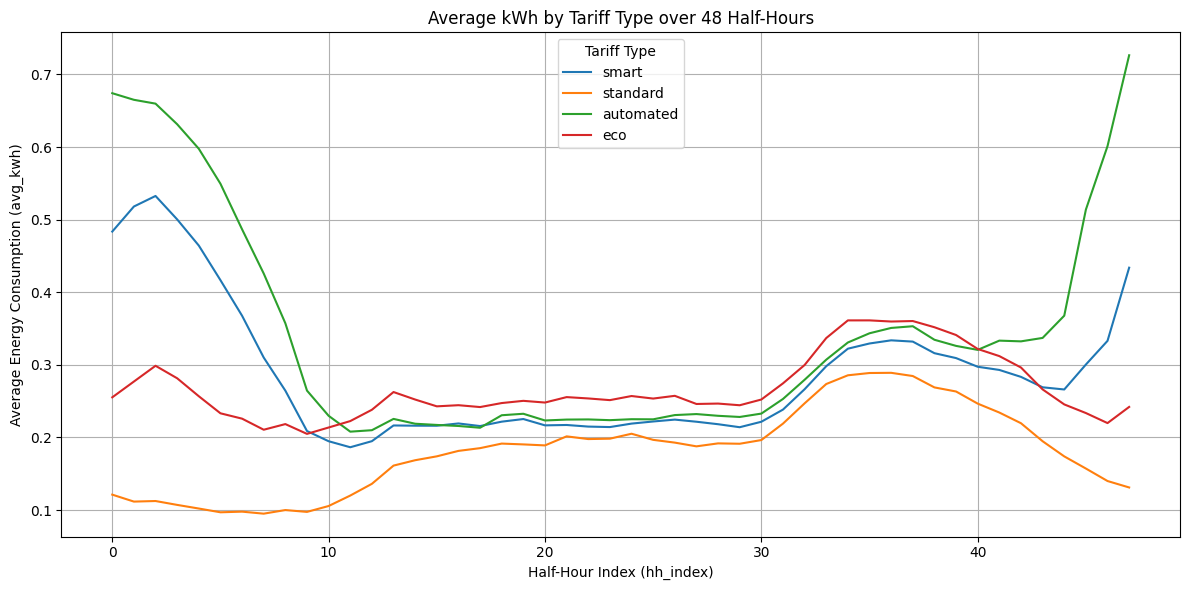

In [2]:
sample_property = extract_by_property_type(['Flat', 'Terraced'], wide=True)
sample_ber = extract_by_energy_rating(['A_B_C', 'D_E'], wide=True)
filtered = extract_filtered(property_types='Flat', energy_ratings='A_B_C', wide=True)
visualize_by_tariff_type(filtered)

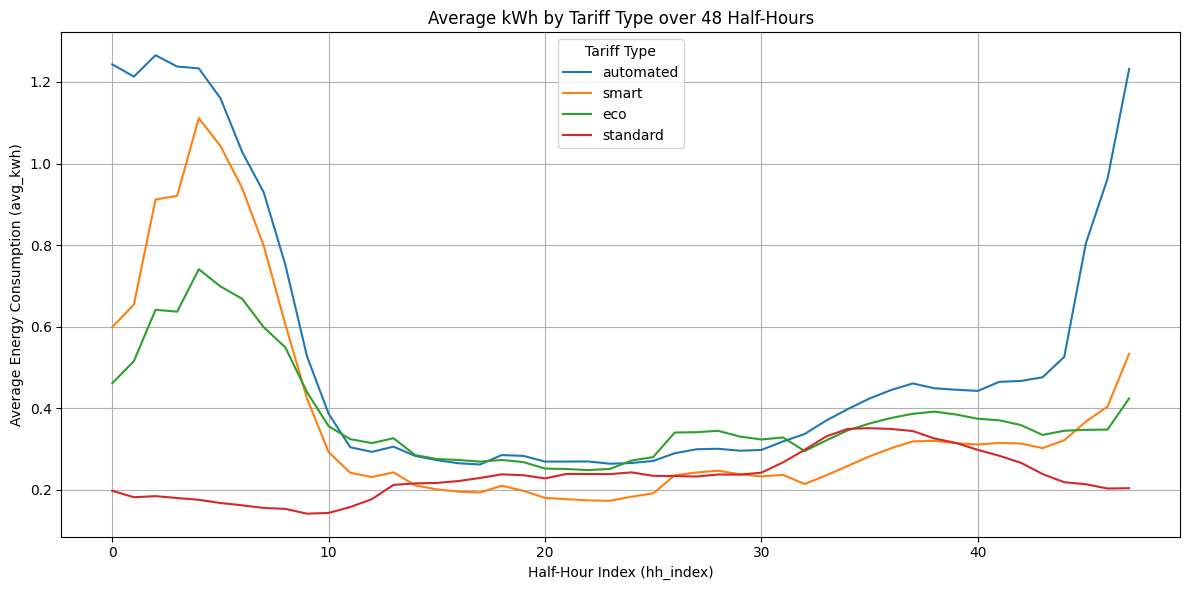

In [3]:
sample_property2 = extract_by_property_type(['Detached'], wide=True)
sample_ber2 = extract_by_energy_rating(['D_E'], wide=True)
filtered2 = extract_filtered(property_types='Detached', energy_ratings='D_E', wide=True)
visualize_by_tariff_type(filtered2)